<a href="https://colab.research.google.com/github/lhammach/DP-representations/blob/main/cka_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CKA analysis of ResNet18 representations


This notebook compares internal representations learned by:

- Baseline ResNet18
- DP-SGD ResNet18

using Centered Kernel Alignment (CKA).

The models were trained separately and saved as checkpoints.

## 0. Setup

In [4]:
!pip install opacus

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.9/308.9 kB 8.4 MB/s eta 0:00:00


In [24]:
# 1. Téléchargement
!wget https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz

# 2. Extraction avec affichage limité
!mkdir -p cifar10
!tar -xzf cifar10.tgz -C cifar10 --strip-components=1
!find cifar10 | head -n 5

# 3. Nettoyage de l'archive après extraction
!rm cifar10.tgz

--2026-06-19 08:56:53--  https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz
Resolving s3.amazonaws.com (s3.amazonaws.com)... 52.217.206.72, 54.231.224.40, 52.217.64.6, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|52.217.206.72|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 135107811 (129M) [application/x-tar]
Saving to: ‘cifar10.tgz’

cifar10.tgz         100%[===================>] 128.85M  34.5MB/s    in 4.1s    

2026-06-19 08:56:58 (31.8 MB/s) - ‘cifar10.tgz’ saved [135107811/135107811]

cifar10
cifar10/test
cifar10/test/truck
cifar10/test/truck/0637.png
cifar10/test/truck/0028.png


In [31]:
import os

import torch
import torchvision.transforms as transforms

from torchvision.datasets import ImageFolder
from torchvision import models

import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [33]:
CHECKPOINT_DIR = "/content/drive/MyDrive/cka_project/checkpoints"
print(os.listdir(CHECKPOINT_DIR))

['baseline_resnet18.pth', 'dp_resnet18_eps50.pth']


## 1. Dataset

We load CIFAR10 exactly as during training.

Using the same normalization is critical because activations depend on input scaling.

In [35]:
# These values, specific to the CIFAR10 dataset, are assumed to be known.
# If necessary, they can be computed with modest privacy budgets.
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD_DEV = (0.2023, 0.1994, 0.2010)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD_DEV),
])

# Loading CIFAR10 (avec ImageFolder)
DATA_ROOT = './cifar10'
train_dataset = ImageFolder(root='./cifar10/train', transform=transform)
test_dataset = ImageFolder(root='./cifar10/test', transform=transform)

print(f"Dataset prêt ! Nombre d'images d'entraînement : {len(train_dataset)}")
image, label = train_dataset[0]
print(image.shape)
print(label)

Dataset prêt ! Nombre d'images d'entraînement : 50000
torch.Size([3, 32, 32])
0


## 2. Rebuild models

We recreate the exact architecture used during training
and load saved weights.

### 2.1 Baseline

In [36]:
baseline = models.resnet18(num_classes=10)

### 2.2 DP model

We do exactly the same corrections as in the notebook where the models are trained.

In [37]:
dp_model = models.resnet18(num_classes=10)

# corrections

from torchvision.models.resnet import BasicBlock

def safe_forward(self, x):
    identity = x

    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)

    out = self.conv2(out)
    out = self.bn2(out)

    if self.downsample is not None:
        identity = self.downsample(x)

    out = out + identity
    out = self.relu(out)

    return out

BasicBlock.forward = safe_forward

# desactivate inplace ReLU

for module in dp_model.modules():
    if isinstance(module, nn.ReLU):
        module.inplace = False

# Conversion BatchNorm -> GroupNorm

from opacus.validators import ModuleValidator

dp_model = ModuleValidator.fix(dp_model)

### 2.3 Load checkpoints

In [41]:
baseline.load_state_dict(
    torch.load(
        f"{CHECKPOINT_DIR}/baseline_resnet18.pth",
        map_location="cpu"
    )
)

dp_model.load_state_dict(
    torch.load(
        f"{CHECKPOINT_DIR}/dp_resnet18_eps50.pth",
        map_location="cpu"
    )
)

print("Models loaded.")


device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

baseline.to(device)
dp_model.to(device)

baseline.eval()
dp_model.eval()


baseline.eval()
dp_model.eval()

Models loaded.


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): GroupNorm(32, 64, eps=1e-05, affine=True)
  (relu): ReLU()
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): GroupNorm(32, 64, eps=1e-05, affine=True)
      (relu): ReLU()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): GroupNorm(32, 64, eps=1e-05, affine=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): GroupNorm(32, 64, eps=1e-05, affine=True)
      (relu): ReLU()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): GroupNorm(32, 64, eps=1e-05, affine=True)
    )
  )
  (layer2): Sequential(
    (0):

## 3. Extract representations

In [42]:
layers = [
    "layer1",
    "layer2",
    "layer3",
    "layer4",
]

### 3.1 Hook utility

In [43]:
def get_activations(model, layer_names):
    activations = {}

    def hook_fn(name):
        def hook(module, inp, out):
            activations[name] = out.detach()
        return hook

    hooks = []

    for name, module in model.named_modules():
        if name in layer_names:
            hooks.append(
                module.register_forward_hook(
                    hook_fn(name)
                )
            )

    return activations, hooks

### 3.2 Run one batch

In [44]:
images, labels = next(iter(test_loader))
images = images.to(device)

acts_base, hooks_base = get_activations(
    baseline,
    layers,
)

acts_dp, hooks_dp = get_activations(
    dp_model,
    layers,
)

with torch.no_grad():
    baseline(images)
    dp_model(images)

# withdraw hooks

for h in hooks_base:
    h.remove()

for h in hooks_dp:
    h.remove()

## 4. CKA

We use linear CKA as proposed by Kornblith et al.

### 4.1 HSIC

In [45]:
def gram_linear(x):
    return x @ x.T

def center_gram(K):
    n = K.shape[0]

    H = torch.eye(n, device=K.device)
    H -= torch.ones(n, n, device=K.device) / n

    return H @ K @ H

def hsic(K, L):
    return torch.sum(K * L)

### 4.2 Linear CKA

In [46]:
def linear_cka(X, Y):

    X = X.flatten(1)
    Y = Y.flatten(1)

    K = center_gram(
        gram_linear(X)
    )

    L = center_gram(
        gram_linear(Y)
    )

    hsic_xy = hsic(K, L)

    hsic_xx = hsic(K, K)
    hsic_yy = hsic(L, L)

    return (
        hsic_xy /
        torch.sqrt(hsic_xx * hsic_yy)
    ).item()

## 5. Compute CKA

Similarity by layer.

In [47]:
cka_scores = {}

for layer in layers:

    score = linear_cka(
        acts_base[layer],
        acts_dp[layer],
    )

    cka_scores[layer] = score

    print(layer, score)

layer1 0.14817500114440918
layer2 0.08093760162591934
layer3 0.06259442120790482
layer4 0.04592844098806381


## 6. Plot

Similarity across layers.

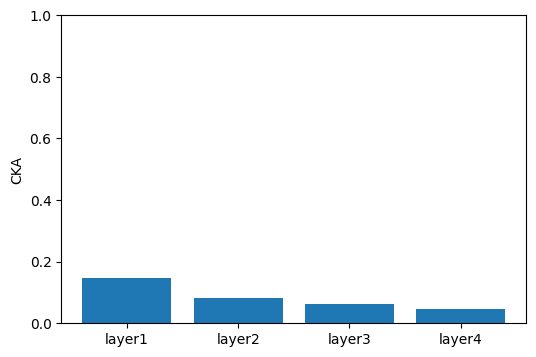

In [48]:
plt.figure(figsize=(6,4))

plt.bar(
    list(cka_scores.keys()),
    list(cka_scores.values()),
)

plt.ylabel("CKA")
plt.ylim(0,1)

plt.show()